# Decline and Reversal EDA -- MOEX

Exploratory analysis of individual stock behavior after sustained price declines on MOEX. Questions: how often do declines of -7% to -20% over 10 days lead to reversals, what is the typical forward return profile, and which intraday signals (TFI, OFI) predict reversals. Data: AlgoPack 5-min bars aggregated to daily level for the MOEX top-40 universe.

In [9]:
import os, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Тикеры (все 48 из AlgoPack)
TICKERS = [
    'AFLT','ALRS','AQUA','BANE','BANEP','BSPB','CHMF','ENRU','FEES','FESH',
    'FIVE','GAZP','GMKN','IRAO','LKOH','LSNGP','LSRG','MAGN','MGNT','MOEX',
    'MRKS','MSNG','MTSS','MVID','NLMK','NVTK','OZON','PHOR','PLZL','POLY',
    'POSI','QIWI','RENI','ROSN','RUAL','SBER','SBERP','SELG','SNGS','SNGSP',
    'TATN','TATNP','TCSG','TRMK','TRNFP','VKCO','VTBR','YNDX'
]

BASE_DIR = '/Users/aakhrameshin/Documents/Side projects/ru_trade'
TMP_DIR  = '/tmp/ru_trade_algopack'
print(f'Тикеров: {len(TICKERS)}')

Тикеров: 48


## 1. Data Loading

In [10]:
def copy_to_tmp(table, ticker):
    src = f'{BASE_DIR}/data/cache/algopack/{table}/{ticker}.parquet'
    dst = f'{TMP_DIR}/{table}/{ticker}.parquet'
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    if not os.path.exists(dst) or os.path.getsize(dst) != os.path.getsize(src):
        shutil.copy2(src, dst)
    return dst

def load_table(table, tickers=None):
    if tickers is None:
        tickers = TICKERS
    frames = []
    missing = []
    for t in tickers:
        src = f'{BASE_DIR}/data/cache/algopack/{table}/{t}.parquet'
        if not os.path.exists(src):
            missing.append(t)
            continue
        dst = copy_to_tmp(table, t)
        frames.append(pd.read_parquet(dst))
    if missing:
        print(f'  [{table}] отсутствуют: {missing}')
    df = pd.concat(frames, ignore_index=True)
    df['ts'] = pd.to_datetime(df['ts'])
    return df.sort_values(['ticker', 'ts']).reset_index(drop=True)

ts_raw = load_table('tradestats')
print(f'  tradestats: {len(ts_raw):,} строк')

ob_raw = load_table('obstats')
print(f'  obstats:    {len(ob_raw):,} строк')

or_raw = load_table('orderstats')
print(f'  orderstats: {len(or_raw):,} строк')

print('Готово.')

Загрузка tradestats...
  tradestats: 6,857,289 строк
Загрузка obstats...
  obstats:    7,016,134 строк
Загрузка orderstats...
  orderstats: 7,009,647 строк
Готово.


## 2. Daily Feature Table

Aggregate 5-min bars to daily: close price (last bar), TFI (disb median), intraday volatility (std of 5-min closes), total volume.

In [11]:
# Дневная агрегация tradestats 
# Цена закрытия = close последнего 5-мин бара за день
# TFI (Trade Flow Imbalance) = медиана disb за день
# Объём торгов для фильтра ликвидности
# Внутридневная волатильность = std(pr_close за 5-мин бары)

ts_daily = (
    ts_raw
    .assign(date=ts_raw['ts'].dt.date)
    .groupby(['ticker', 'date'])
    .agg(
        open        = ('pr_open',  'first'),
        close       = ('pr_close', 'last'),
        high        = ('pr_high',  'max'),
        low         = ('pr_low',   'min'),
        vol_total   = ('vol',       'sum'),
        val_total   = ('val',       'sum'),
        tfi_median  = ('disb',      'median'),   # TFI: медиана (устойчивее среднего)
        tfi_mean    = ('disb',      'mean'),
        tfi_q80     = ('disb',      lambda x: x.quantile(0.8)),
        intraday_vol= ('pr_close',  'std'),       # волатильность внутри дня
        n_bars      = ('pr_close',  'count'),
    )
    .reset_index()
)
ts_daily['date'] = pd.to_datetime(ts_daily['date'])

ob_daily = (
    ob_raw
    .assign(date=ob_raw['ts'].dt.date)
    .groupby(['ticker', 'date'])
    .agg(
        ofi_vol_median   = ('imbalance_vol',     'median'),
        ofi_vol_mean     = ('imbalance_vol',     'mean'),
        ofi_val_median   = ('imbalance_val',     'median'),
        spread_bbo_q80   = ('spread_bbo',        lambda x: x.quantile(0.8)),
        spread_bbo_med   = ('spread_bbo',        'median'),
    )
    .reset_index()
)
ob_daily['date'] = pd.to_datetime(ob_daily['date'])

or_daily = (
    or_raw
    .assign(date=or_raw['ts'].dt.date)
    .groupby(['ticker', 'date'])
    .agg(
        cancel_vol_b = ('cancel_vol_b', 'sum'),
        cancel_vol_s = ('cancel_vol_s', 'sum'),
        put_vol_b    = ('put_vol_b',    'sum'),
        put_vol_s    = ('put_vol_s',    'sum'),
    )
    .reset_index()
)
or_daily['date'] = pd.to_datetime(or_daily['date'])

# cancel_delta > 0 продавцы отменяют агрессивнее бычий знак
or_daily['cancel_ratio_b'] = or_daily['cancel_vol_b'] / (or_daily['put_vol_b'] + 1)
or_daily['cancel_ratio_s'] = or_daily['cancel_vol_s'] / (or_daily['put_vol_s'] + 1)
or_daily['cancel_delta']   = or_daily['cancel_ratio_s'] - or_daily['cancel_ratio_b']

daily = (
    ts_daily
    .merge(ob_daily, on=['ticker', 'date'], how='left')
    .merge(or_daily[['ticker','date','cancel_delta','cancel_ratio_b','cancel_ratio_s']], on=['ticker', 'date'], how='left')
)

print(f'Дневных строк: {len(daily):,}  |  Тикеров: {daily["ticker"].nunique()}  |  Период: {daily["date"].min().date()} → {daily["date"].max().date()}')
daily.head(3)

Дневных строк: 43,098  |  Тикеров: 48  |  Период: 2023-01-03 → 2026-06-13


,ticker,date,open,close,high,low,vol_total,val_total,tfi_median,tfi_mean,...,intraday_vol,n_bars,ofi_vol_median,ofi_vol_mean,ofi_val_median,spread_bbo_q80,spread_bbo_med,cancel_delta,cancel_ratio_b,cancel_ratio_s
0,AFLT,2023-01-03,24.68,24.64,24.80,24.60,185970,45928578,0.30,0.153292,...,0.032167,161,0.10,0.098447,0.03,10.0,8.1,0.014322,0.890472,0.904794
1,AFLT,2023-01-04,24.66,25.04,25.08,24.62,305427,76075832,-0.05,0.037764,...,0.092728,161,0.14,0.139317,0.08,10.7,8.1,-0.002002,0.908508,0.906505
2,AFLT,2023-01-05,25.02,25.60,25.90,25.00,1127489,288145629,0.07,0.069565,...,0.116096,161,0.16,0.168261,0.11,10.4,8.6,-0.049116,0.921887,0.872770


## 3. Rolling Metrics

- `ret_1d` -- daily return
- `ret_Nd` -- cumulative N-day return (5, 10, 15, 20)
- `rvol_10d` -- realized volatility over 10 days (annualized)
- All metrics computed without look-ahead (shift(1) before rolling)

In [12]:
daily = daily.sort_values(['ticker', 'date']).reset_index(drop=True)

def add_rolling(df):
    g = df.copy()
    g['ret_1d'] = g['close'].pct_change()
    for n in [5, 10, 15, 20]:
        g[f'ret_{n}d'] = g['close'].pct_change(n)
    log_ret = np.log(g['close'] / g['close'].shift(1))
    for n in [5, 10, 20]:
        g[f'rvol_{n}d'] = log_ret.rolling(n).std() * np.sqrt(252)
    for n in [1, 3, 5, 7]:
        g[f'fwd_{n}d'] = g['close'].pct_change(n).shift(-n)
    g['tfi_roll5']     = g['tfi_median'].rolling(5).mean()
    g['ofi_vol_roll5'] = g['ofi_vol_median'].rolling(5).mean()
    g['cancel_roll5']  = g['cancel_delta'].rolling(5).mean()
    return g

# Явный цикл вместо groupby().apply()  избегаем потери колонки 'ticker'
# (pandas 2.x убирает ключ группировки из колонок при apply)
frames = []
for ticker, grp in daily.groupby('ticker'):
    frames.append(add_rolling(grp))
daily = pd.concat(frames, ignore_index=True)
daily = daily.dropna(subset=['ret_10d', 'rvol_10d']).reset_index(drop=True)

print(f'После добавления rolling метрик: {len(daily):,} строк')
print(daily[['ticker','date','close','ret_1d','ret_10d','rvol_10d','tfi_median','ofi_vol_median','cancel_delta']].head(5).to_string())

После добавления rolling метрик: 42,618 строк
  ticker       date  close    ret_1d   ret_10d  rvol_10d  tfi_median  ofi_vol_median  cancel_delta
0   AFLT 2023-01-17  27.44 -0.046560  0.113636  0.406170       -0.10            0.18      0.051179
1   AFLT 2023-01-18  27.56  0.004373  0.100639  0.406123        0.05            0.18      0.000044
2   AFLT 2023-01-19  27.48 -0.002903  0.073438  0.403930       -0.02            0.19     -0.027450
3   AFLT 2023-01-20  27.80  0.011645  0.091909  0.398102       -0.01            0.24      0.021433
4   AFLT 2023-01-23  27.80  0.000000  0.065951  0.390515        0.19           -0.10     -0.044602


## 4. Distribution of Sustained Declines

Distribution of `ret_10d` and `ret_15d` across all tickers and dates -- to determine reasonable decline thresholds for signal construction.

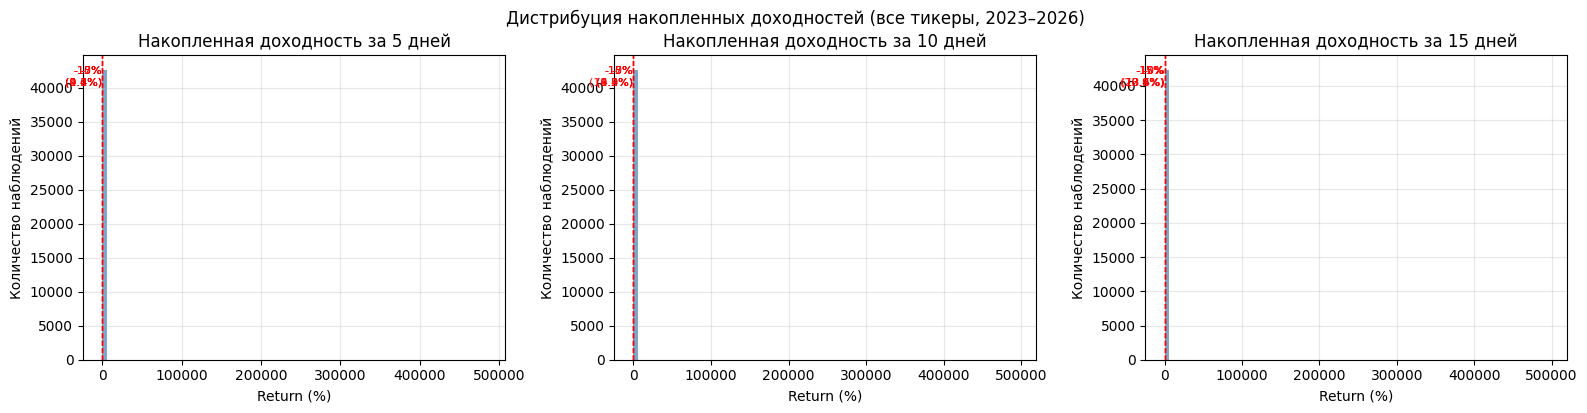


Количество сетапов «падение N%» (≈ независимых):
   Порог |   ret_5d |   ret_10d |   ret_15d
---------------------------------------------
     -5% |    3,933 |     6,914 |     8,796
     -7% |    1,860 |     4,206 |     5,769
    -10% |      684 |     1,885 |     2,945
    -12% |      369 |     1,144 |     1,865
    -15% |      158 |       533 |     1,004
    -20% |       61 |       171 |       362


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, label in zip(axes, ['ret_5d','ret_10d','ret_15d'], ['5 дней','10 дней','15 дней']):
    data = daily[col].dropna() * 100
    ax.hist(data, bins=80, color='steelblue', alpha=0.7, edgecolor='none')
    for pct in [-15, -10, -7, -5]:
        cnt = (data < pct).sum()
        pct_of_total = cnt / len(data) * 100
        ax.axvline(pct, color='red', lw=1, linestyle='--', alpha=0.6)
        ax.text(pct, ax.get_ylim()[1]*0.9, f'{pct}%\n({pct_of_total:.1f}%)', 
                fontsize=8, color='red', ha='right')
    ax.set_title(f'Накопленная доходность за {label}')
    ax.set_xlabel('Return (%)')
    ax.set_ylabel('Количество наблюдений')

plt.tight_layout()
plt.suptitle('Дистрибуция накопленных доходностей (все тикеры, 2023–2026)', y=1.02, fontsize=12)
plt.show()

# Сколько уникальных сетапов при разных порогах (1 раз на тикер, если нет новых 10 дней)
print('\nКоличество сетапов «падение N%» (≈ независимых):')    
print(f'{"Порог":>8} | {"ret_5d":>8} | {"ret_10d":>9} | {"ret_15d":>9}')
print('-' * 45)
for thr in [-5, -7, -10, -12, -15, -20]:
    c5  = (daily['ret_5d']  < thr/100).sum()
    c10 = (daily['ret_10d'] < thr/100).sum()
    c15 = (daily['ret_15d'] < thr/100).sum()
    print(f'{thr:>7}% | {c5:>8,} | {c10:>9,} | {c15:>9,}')

## 5. Forward Returns After Decline

For each decline threshold on 10-day return, compute mean forward return at 1, 3, 5, 7 days.

Форвардные доходности после падения ret_10d < порог
   Порог |      N |     1 день |      3 дня |     5 дней |     7 дней
-----------------------------------------------------------------
     -5% |  6,914 |    -0.01%  |    +0.09%  |    +0.32%* |    +0.45%*
     -7% |  4,206 |    +0.06%  |    +0.23%* |    +0.53%* |    +0.70%*
    -10% |  1,885 |    +0.12%  |    +0.38%* |    +0.84%* |    +1.09%*
    -12% |  1,144 |    +0.22%  |    +0.61%* |    +1.19%* |    +1.49%*
    -15% |    533 |    +0.41%* |    +0.80%* |    +1.43%* |    +1.63%*
    -20% |    171 |    +0.74%  |    +1.10%  |    +1.12%  |    +1.14% 

* = p < 0.05


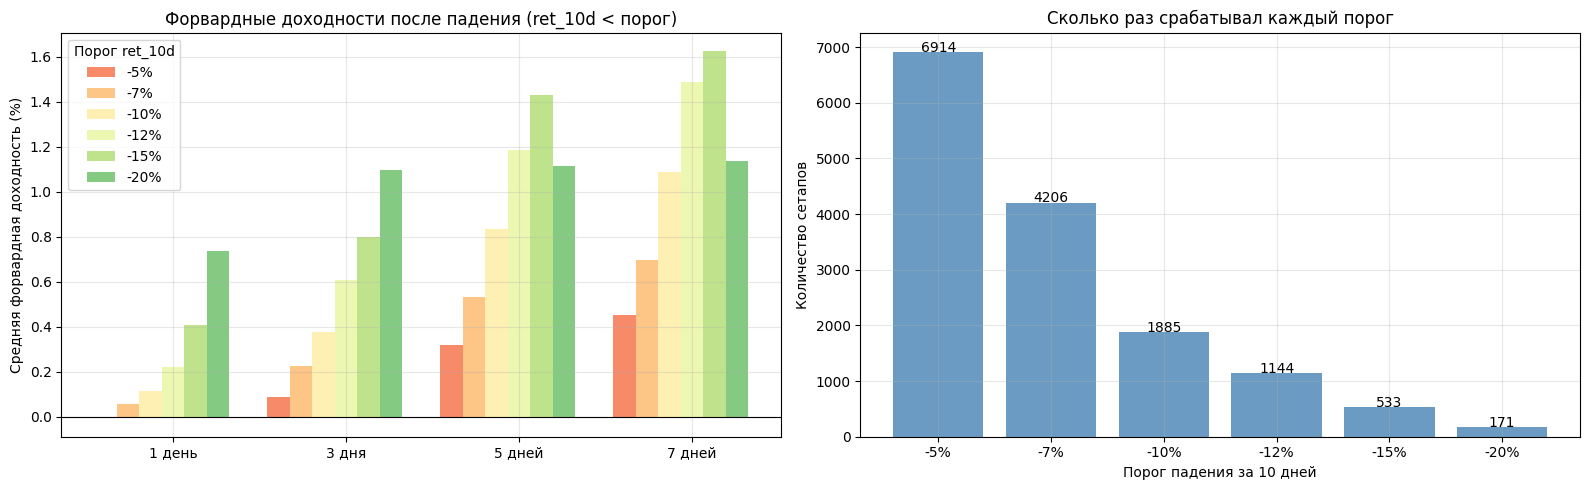

In [15]:
thresholds = [-0.05, -0.07, -0.10, -0.12, -0.15, -0.20]
fwd_cols   = ['fwd_1d', 'fwd_3d', 'fwd_5d', 'fwd_7d']
labels     = ['1 день', '3 дня', '5 дней', '7 дней']

print(f'Форвардные доходности после падения ret_10d < порог')
print(f'{"Порог":>8} | {"N":>6} | ' + ' | '.join(f'{l:>10}' for l in labels))
print('-' * 65)

results = []
for thr in thresholds:
    mask = daily['ret_10d'] < thr
    sub  = daily[mask]
    row = {'threshold': thr, 'n': len(sub)}
    means = []
    for col in fwd_cols:
        m = sub[col].mean() * 100
        t, p = stats.ttest_1samp(sub[col].dropna(), 0)
        row[col] = m
        row[f'{col}_p'] = p
        sig = '*' if p < 0.05 else ' '
        means.append(f'{m:>+.2f}%{sig}')
    results.append(row)
    print(f'{thr*100:>7.0f}% | {len(sub):>6,} | ' + ' | '.join(f'{m:>10}' for m in means))

print('\n* = p < 0.05')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(thresholds)))
x = np.arange(len(fwd_cols))
width = 0.13
for i, (thr, r) in enumerate(zip(thresholds, results)):
    vals = [r[c] for c in fwd_cols]
    ax.bar(x + i*width, vals, width, label=f'{thr*100:.0f}%', color=colors[i], alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x + width*len(thresholds)/2)
ax.set_xticklabels(labels)
ax.set_ylabel('Средняя форвардная доходность (%)')
ax.set_title('Форвардные доходности после падения (ret_10d < порог)')
ax.legend(title='Порог ret_10d')

ax2 = axes[1]
ns = [r['n'] for r in results]
thrx = [f'{t*100:.0f}%' for t in thresholds]
ax2.bar(thrx, ns, color='steelblue', alpha=0.8)
for i, n in enumerate(ns):
    ax2.text(i, n+5, str(n), ha='center', fontsize=10)
ax2.set_xlabel('Порог падения за 10 дней')
ax2.set_ylabel('Количество сетапов')
ax2.set_title('Сколько раз срабатывал каждый порог')

plt.tight_layout()
plt.show()

## 6. OFI and TFI Profile: Decline vs Reversal Days

TFI and OFI distribution across return quintiles (Q1=worst to Q5=best 10-day return).

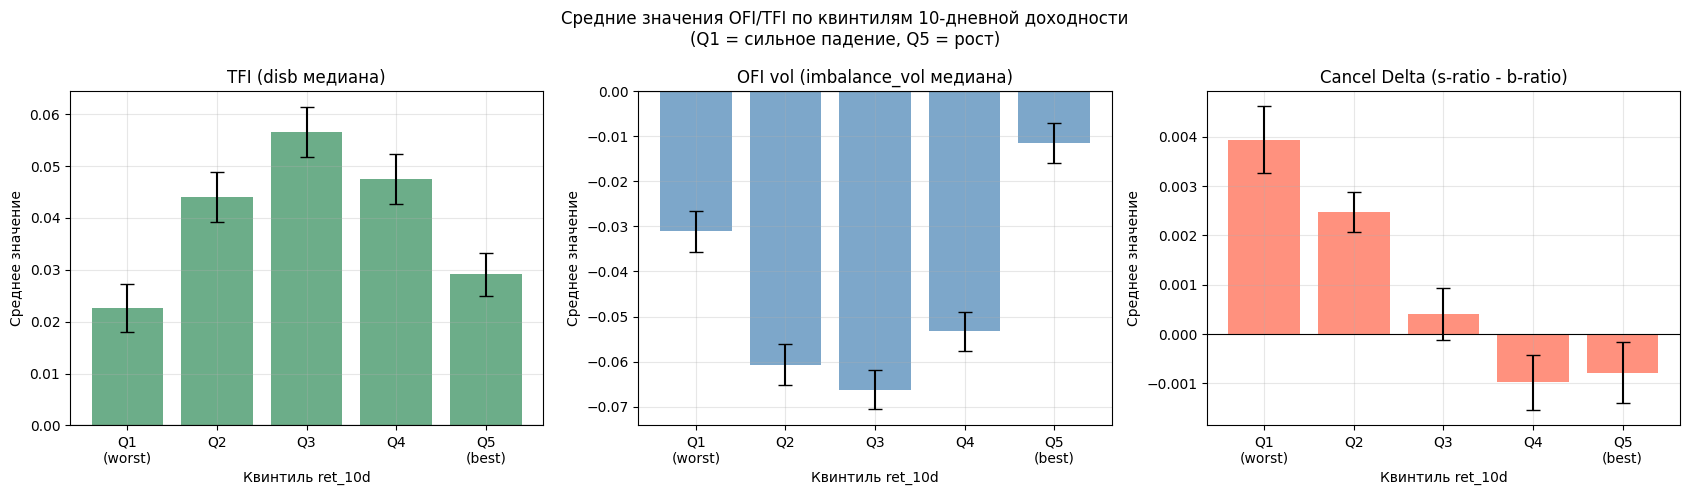

                tfi_median  ofi_vol_median  cancel_delta  ret_10d
ret10_quintile                                                   
Q1\n(worst)         0.0226         -0.0311        0.0039  -0.0840
Q2                  0.0441         -0.0607        0.0025  -0.0257
Q3                  0.0566         -0.0662        0.0004   0.0001
Q4                  0.0475         -0.0532       -0.0010   0.0278
Q5\n(best)          0.0292         -0.0116       -0.0008   5.5753


In [16]:
# Разбиваем все дни на 5 бакетов по ret_10d
daily['ret10_quintile'] = pd.qcut(daily['ret_10d'], 5, labels=['Q1\n(worst)','Q2','Q3','Q4','Q5\n(best)'])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics = [
    ('tfi_median',      'TFI (disb медиана)',            'seagreen'),
    ('ofi_vol_median',  'OFI vol (imbalance_vol медиана)', 'steelblue'),
    ('cancel_delta',    'Cancel Delta (s-ratio - b-ratio)', 'tomato'),
]

for ax, (col, title, color) in zip(axes, metrics):
    grp = daily.groupby('ret10_quintile', observed=True)[col]
    means = grp.mean()
    ci    = grp.sem() * 1.96
    ax.bar(means.index, means, yerr=ci, color=color, alpha=0.7, capsize=5)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(title)
    ax.set_xlabel('Квинтиль ret_10d')
    ax.set_ylabel('Среднее значение')

plt.suptitle('Средние значения OFI/TFI по квинтилям 10-дневной доходности\n(Q1 = сильное падение, Q5 = рост)', 
             fontsize=12)
plt.tight_layout()
plt.show()

# Таблица
print(daily.groupby('ret10_quintile', observed=True)[['tfi_median','ofi_vol_median','cancel_delta','ret_10d']].mean().round(4).to_string())

## 7. OFI Sign Change at Reversal

Key question: does OFI sign change during a reversal after a decline? Days where `ret_10d < -10%` (accumulated decline) and `fwd_5d > 0` (reversal started) vs continuation days.

Дней в падении (ret_10d < -10%): 1,885
  → разворот (fwd_5d > 0): 1,037  (55.0%)
  → продолжение вниз:      833  (44.2%)

             Метрика |     Разворот |  Продолжение |    Разница |  p-value
---------------------------------------------------------------------------
          TFI (disb) |       0.0045 |       0.0092 |    -0.0047 |  0.6330 
             OFI vol |      -0.0116 |      -0.0588 |    +0.0472 |  0.0000 ***
        Cancel Delta |       0.0057 |       0.0047 |    +0.0010 |  0.5297 
        Intraday Vol |       7.7332 |       8.5618 |    -0.8286 |  0.4880 
            RVol 10d |       0.6018 |       1.0242 |    -0.4225 |  0.0007 ***


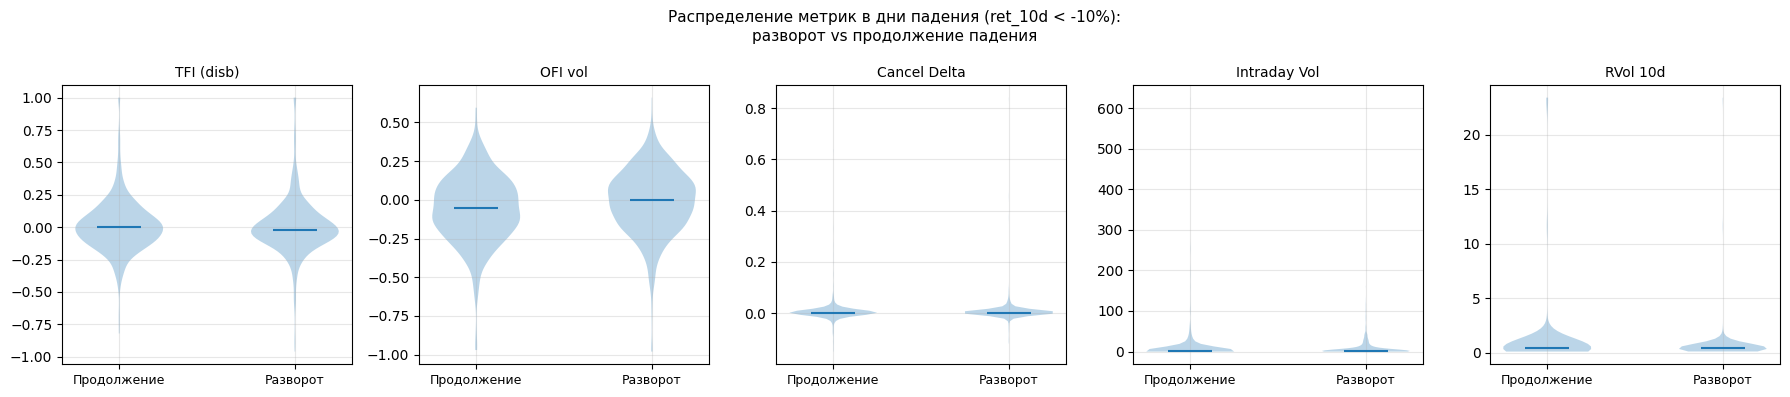

In [17]:
DECLINE_THR = -0.10   # порог падения
FWD_THR     =  0.00   # разворот = положительная форвардная доходность

in_decline    = daily['ret_10d'] < DECLINE_THR
reversal_days = in_decline & (daily['fwd_5d'] > FWD_THR)
continue_days = in_decline & (daily['fwd_5d'] <= FWD_THR)

print(f'Дней в падении (ret_10d < {DECLINE_THR*100:.0f}%): {in_decline.sum():,}')
print(f'  → разворот (fwd_5d > 0): {reversal_days.sum():,}  ({reversal_days.sum()/in_decline.sum()*100:.1f}%)')
print(f'  → продолжение вниз:      {continue_days.sum():,}  ({continue_days.sum()/in_decline.sum()*100:.1f}%)')

metrics = ['tfi_median', 'ofi_vol_median', 'cancel_delta', 'intraday_vol', 'rvol_10d']
labels_m = ['TFI (disb)', 'OFI vol', 'Cancel Delta', 'Intraday Vol', 'RVol 10d']

print(f'\n{"Метрика":>20} | {"Разворот":>12} | {"Продолжение":>12} | {"Разница":>10} | {"p-value":>8}')
print('-' * 75)

diffs = []
for col, lbl in zip(metrics, labels_m):
    rev  = daily.loc[reversal_days,  col].dropna()
    cont = daily.loc[continue_days,  col].dropna()
    diff = rev.mean() - cont.mean()
    t, p = stats.ttest_ind(rev, cont, equal_var=False)
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    print(f'{lbl:>20} | {rev.mean():>12.4f} | {cont.mean():>12.4f} | {diff:>+10.4f} | {p:>7.4f} {sig}')
    diffs.append({'metric': lbl, 'reversal': rev.mean(), 'continuation': cont.mean(), 'p': p})

# --- Визуализация ---
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))
for ax, (col, lbl) in zip(axes, zip(metrics, labels_m)):
    rev  = daily.loc[reversal_days,  col].dropna()
    cont = daily.loc[continue_days, col].dropna()
    ax.violinplot([cont, rev], positions=[0,1], showmedians=True, showextrema=False)
    ax.set_xticks([0,1])
    ax.set_xticklabels(['Продолжение', 'Разворот'], fontsize=9)
    ax.set_title(lbl, fontsize=10)

plt.suptitle(f'Распределение метрик в дни падения (ret_10d < {DECLINE_THR*100:.0f}%):\nразворот vs продолжение падения', fontsize=11)
plt.tight_layout()
plt.show()

## 8. IC Analysis -- What Predicts Reversals?

For days in decline, compute Information Coefficient (Spearman rank correlation) between each signal and forward return.

In [18]:
signals = [
    ('tfi_median',      'TFI (disb медиана)'),
    ('tfi_roll5',       'TFI rolling 5d'),
    ('ofi_vol_median',  'OFI vol медиана'),
    ('ofi_vol_roll5',   'OFI vol rolling 5d'),
    ('cancel_delta',    'Cancel delta'),
    ('cancel_roll5',    'Cancel rolling 5d'),
    ('rvol_10d',        'RVol 10d'),
    ('intraday_vol',    'Intraday vol'),
]
fwd_horizons = ['fwd_1d', 'fwd_3d', 'fwd_5d', 'fwd_7d']

# Тест 1: весь датасет
# Тест 2: только дни в падении (ret_10d < -10%)
masks = {
    'Все дни':            pd.Series(True, index=daily.index),
    'В падении (<-10%)':  daily['ret_10d'] < -0.10,
    'В падении (<-7%)':   daily['ret_10d'] < -0.07,
}

from scipy.stats import spearmanr

for mask_name, mask in masks.items():
    sub = daily[mask]
    print(f'\n=== {mask_name} (N={len(sub):,}) ===')
    print(f'{"Сигнал":>25} | ' + ' | '.join(f'{h:>10}' for h in ['fwd_1d','fwd_3d','fwd_5d','fwd_7d']))
    print('-' * 75)
    for col, lbl in signals:
        row_vals = []
        for fwd in fwd_horizons:
            valid = sub[[col, fwd]].dropna()
            if len(valid) < 30:
                row_vals.append('  ---  ')
                continue
            ic, p = spearmanr(valid[col], valid[fwd])
            sig = '*' if p < 0.05 else ' '
            row_vals.append(f'{ic:>+.3f}{sig}')
        print(f'{lbl:>25} | ' + ' | '.join(f'{v:>10}' for v in row_vals))

print('\n* = p < 0.05')


=== Все дни (N=42,618) ===
                   Сигнал |     fwd_1d |     fwd_3d |     fwd_5d |     fwd_7d
---------------------------------------------------------------------------
       TFI (disb медиана) |    +0.025* |    +0.025* |    +0.033* |    +0.032*
           TFI rolling 5d |    +0.023* |    +0.026* |    +0.025* |    +0.022*
          OFI vol медиана |    +0.044* |    +0.054* |    +0.070* |    +0.077*
       OFI vol rolling 5d |    +0.034* |    +0.052* |    +0.065* |    +0.072*
             Cancel delta |    +0.013* |    +0.013* |    +0.010* |    +0.013*
        Cancel rolling 5d |    +0.008  |    +0.014* |    +0.014* |    +0.018*
                 RVol 10d |    +0.001  |    +0.029* |    +0.038* |    +0.048*
             Intraday vol |    +0.006  |    +0.014* |    +0.012* |    +0.010*

=== В падении (<-10%) (N=1,885) ===
                   Сигнал |     fwd_1d |     fwd_3d |     fwd_5d |     fwd_7d
---------------------------------------------------------------------------
   

## 9. Intraday OFI Profile at Reversal

Take specific reversal days and examine TFI across the trading day (5-min bars). When during the day does the signal appear?

Событий разворота: 1037
Событий продолжения: 833


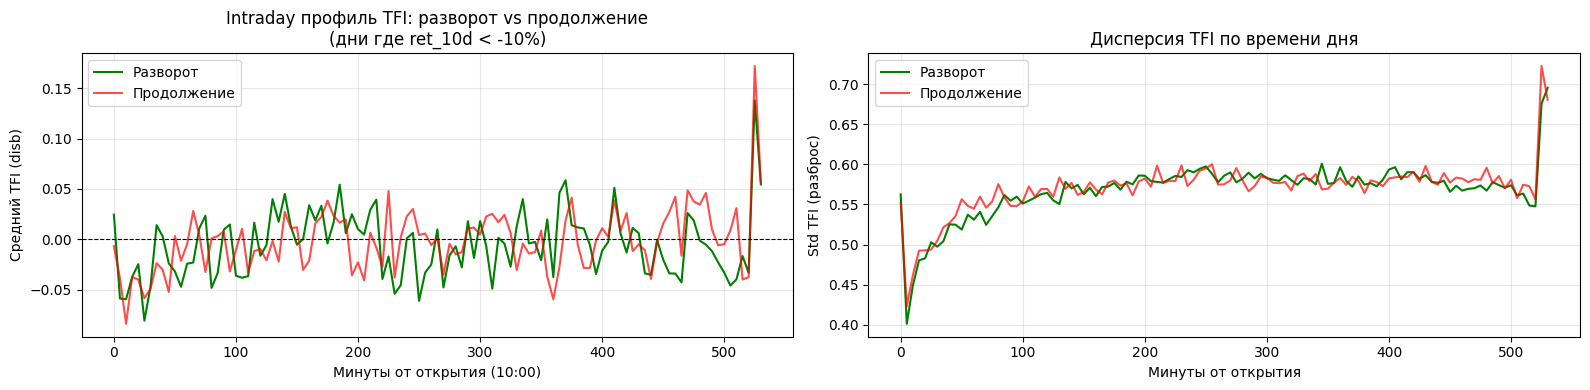

In [19]:
# Дни разворота после падения
reversal_events = daily[reversal_days][['ticker', 'date']].copy()
continuation_events = daily[continue_days][['ticker', 'date']].copy()

print(f'Событий разворота: {len(reversal_events)}')
print(f'Событий продолжения: {len(continuation_events)}')

# Джойним 5-мин tradestats с датами-событиями
ts_raw_copy = ts_raw.copy()
ts_raw_copy['date'] = ts_raw_copy['ts'].dt.date.astype(str)
reversal_events['date'] = reversal_events['date'].astype(str)
continuation_events['date'] = continuation_events['date'].astype(str)

ts_rev  = ts_raw_copy.merge(reversal_events,     on=['ticker','date'], how='inner')
ts_cont = ts_raw_copy.merge(continuation_events, on=['ticker','date'], how='inner')

# Время в минутах от открытия (10:00)
def time_to_min(t):
    h, m, s = str(t).split(':')
    return (int(h) - 10) * 60 + int(m)

ts_rev['min_from_open']  = ts_rev['tradetime'].apply(time_to_min)
ts_cont['min_from_open'] = ts_cont['tradetime'].apply(time_to_min)

# Фильтруем основную сессию 10:00-18:50
ts_rev  = ts_rev[(ts_rev['min_from_open'] >= 0) & (ts_rev['min_from_open'] <= 530)]
ts_cont = ts_cont[(ts_cont['min_from_open'] >= 0) & (ts_cont['min_from_open'] <= 530)]

# Средний TFI (disb) по минутам от открытия
rev_profile  = ts_rev.groupby('min_from_open')['disb'].mean()
cont_profile = ts_cont.groupby('min_from_open')['disb'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
ax.plot(rev_profile.index,  rev_profile.values,  color='green', lw=1.5, label='Разворот')
ax.plot(cont_profile.index, cont_profile.values, color='red',   lw=1.5, label='Продолжение', alpha=0.7)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Минуты от открытия (10:00)')
ax.set_ylabel('Средний TFI (disb)')
ax.set_title('Intraday профиль TFI: разворот vs продолжение\n(дни где ret_10d < -10%)')
ax.legend()

# Rolling std (волатильность внутри дня)
rev_vol  = ts_rev.groupby('min_from_open')['disb'].std()
cont_vol = ts_cont.groupby('min_from_open')['disb'].std()

ax2 = axes[1]
ax2.plot(rev_vol.index,  rev_vol.values,  color='green', lw=1.5, label='Разворот')
ax2.plot(cont_vol.index, cont_vol.values, color='red',   lw=1.5, label='Продолжение', alpha=0.7)
ax2.set_xlabel('Минуты от открытия')
ax2.set_ylabel('Std TFI (разброс)')
ax2.set_title('Дисперсия TFI по времени дня')
ax2.legend()

plt.tight_layout()
plt.show()

## 10. Volatility Role -- Filter Calibration

Does high realized volatility help or hurt the strategy? Break decline-days into rvol quintiles and compare `fwd_5d`.

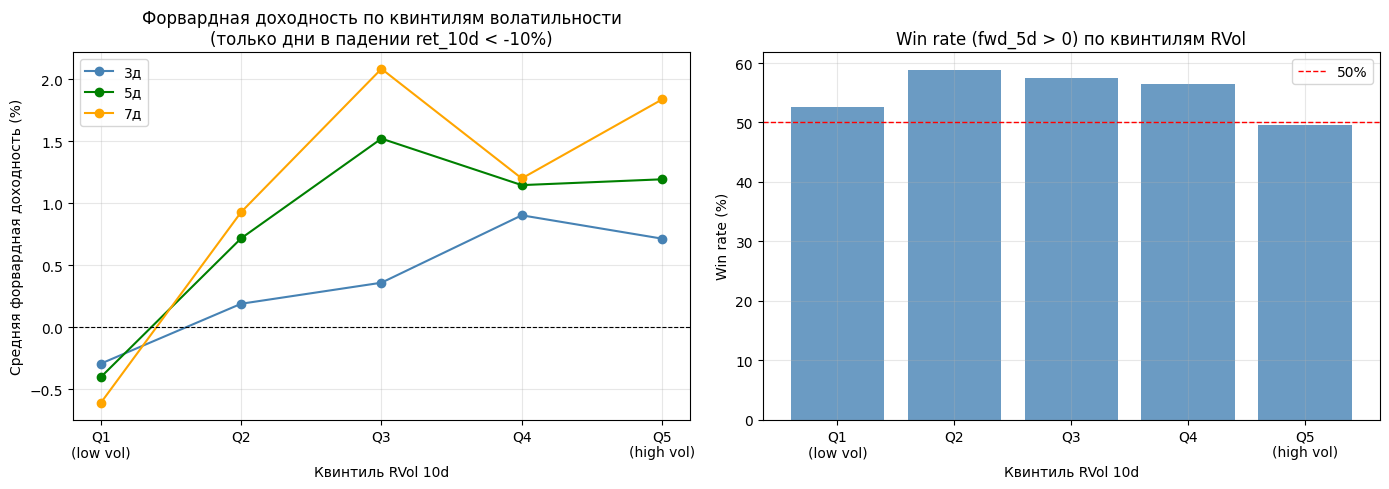

               rvol_10d  fwd_3d  fwd_5d  fwd_7d
rvol_quintile                                  
Q1\n(low vol)   +24.41%  -0.29%  -0.40%  -0.61%
Q2              +33.36%  +0.19%  +0.72%  +0.93%
Q3              +42.09%  +0.36%  +1.52%  +2.08%
Q4              +54.61%  +0.90%  +1.15%  +1.20%
Q5\n(high vol)     2.39  +0.72%  +1.19%  +1.84%


In [21]:
sub_decline = daily[daily['ret_10d'] < -0.10].copy()
sub_decline['rvol_quintile'] = pd.qcut(sub_decline['rvol_10d'], 5, 
                                        labels=['Q1\n(low vol)', 'Q2', 'Q3', 'Q4', 'Q5\n(high vol)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
grp = sub_decline.groupby('rvol_quintile', observed=True)
for fwd, color, lbl in zip(['fwd_3d','fwd_5d','fwd_7d'], ['steelblue','green','orange'], ['3д','5д','7д']):
    means = grp[fwd].mean() * 100
    ax.plot(means.index, means.values, marker='o', label=lbl, color=color)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_title('Форвардная доходность по квинтилям волатильности\n(только дни в падении ret_10d < -10%)')
ax.set_xlabel('Квинтиль RVol 10d')
ax.set_ylabel('Средняя форвардная доходность (%)')
ax.legend()

ax2 = axes[1]
wr = grp['fwd_5d'].apply(lambda x: (x > 0).mean() * 100)
ax2.bar(wr.index, wr.values, color='steelblue', alpha=0.8)
ax2.axhline(50, color='red', lw=1, linestyle='--', label='50%')
ax2.set_title('Win rate (fwd_5d > 0) по квинтилям RVol')
ax2.set_xlabel('Квинтиль RVol 10d')
ax2.set_ylabel('Win rate (%)')
ax2.legend()

plt.tight_layout()
plt.show()

# Числовые значения
fmt = lambda x: f'{x*100:+.2f}%' if abs(x) < 1 else f'{x:.2f}'
print(sub_decline.groupby('rvol_quintile', observed=True)[['rvol_10d','fwd_3d','fwd_5d','fwd_7d']].mean().map(fmt).to_string())

## 11. Decline Length vs Bounce Length

Empirical check: are longer declines followed by longer bounces? Count consecutive declining days and the subsequent rising-day run for each ticker.

Всего серий (≥3 дней падения → ≥1 день роста): 2108

Средняя длина падения: 3.9 дней (-5.9%)
Средняя длина отскока: 1.8 дней (2.8%)


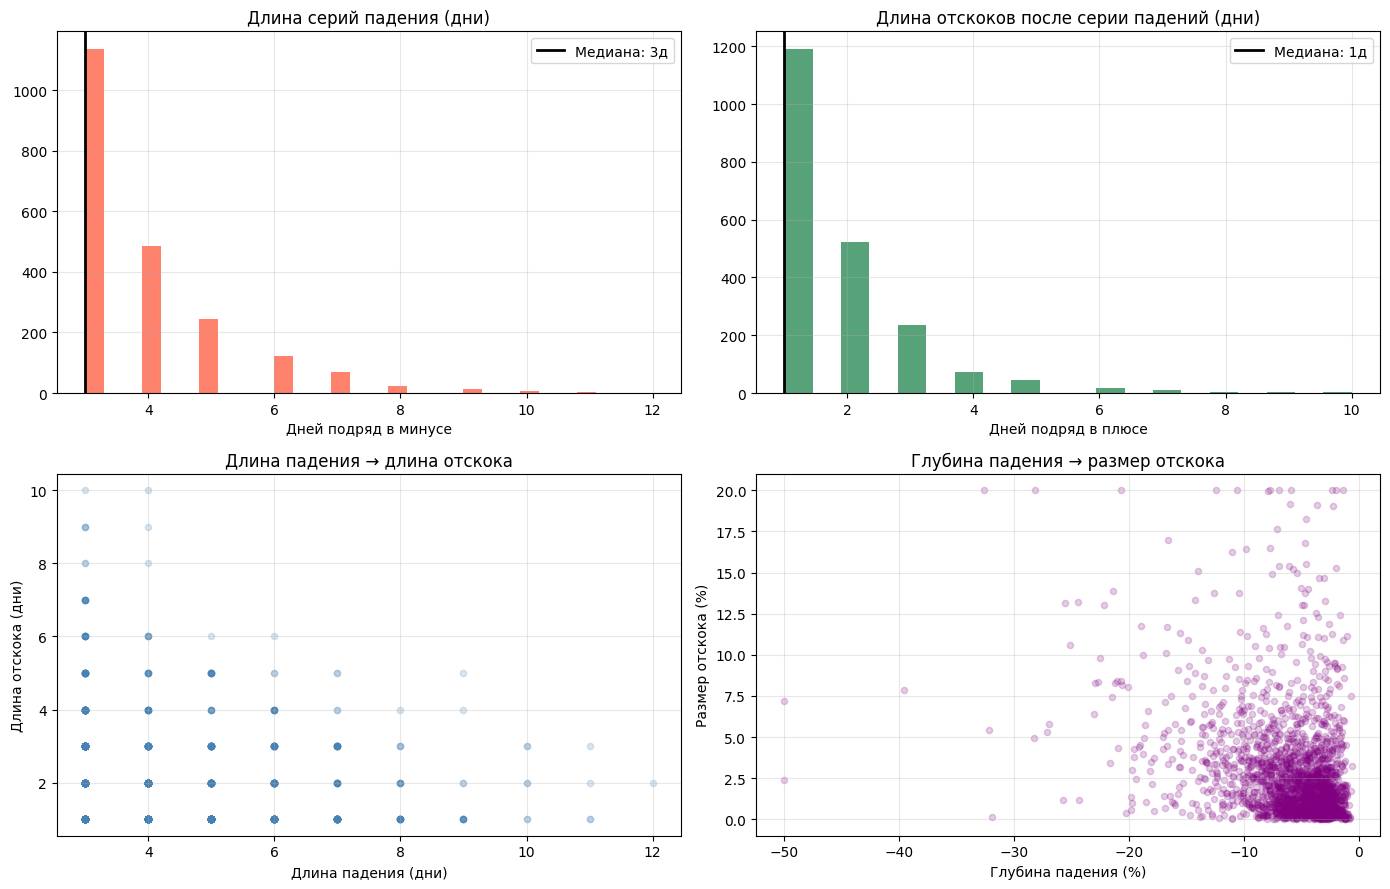


Корреляция (длина_падения, длина_отскока): -0.009
Корреляция (глубина_падения, размер_отскока): -0.275


In [22]:
# Для каждой акции считаем серии: непрерывные падающие дни → потом растущие

def find_sequences(df_ticker):
    """Находит пары (длина_падения, длина_отскока) для одного тикера."""
    ret = df_ticker['ret_1d'].values
    dates = df_ticker['date'].values
    
    sequences = []
    i = 0
    while i < len(ret):
        # Начало падения
        if ret[i] < -0.005:  # падение > 0.5%
            down_start = i
            while i < len(ret) and ret[i] < 0:
                i += 1
            down_len = i - down_start
            down_total = np.sum(ret[down_start:i])
            
            # Отскок после
            up_start = i
            while i < len(ret) and ret[i] > 0:
                i += 1
            up_len = i - up_start
            up_total = np.sum(ret[up_start:i]) if up_len > 0 else 0
            
            if down_len >= 3 and up_len >= 1:  # только значимые серии
                sequences.append({
                    'down_days':  down_len,
                    'down_ret':   down_total * 100,
                    'up_days':    up_len,
                    'up_ret':     up_total * 100,
                })
        else:
            i += 1
    return sequences

all_sequences = []
for ticker, grp in daily.groupby('ticker'):
    seqs = find_sequences(grp.reset_index(drop=True))
    for s in seqs:
        s['ticker'] = ticker
        all_sequences.append(s)

seqs_df = pd.DataFrame(all_sequences)
print(f'Всего серий (≥3 дней падения → ≥1 день роста): {len(seqs_df)}')
print(f'\nСредняя длина падения: {seqs_df["down_days"].mean():.1f} дней ({seqs_df["down_ret"].mean():.1f}%)')
print(f'Средняя длина отскока: {seqs_df["up_days"].mean():.1f} дней ({seqs_df["up_ret"].mean():.1f}%)')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Дистрибуция длины падений
axes[0,0].hist(seqs_df['down_days'].clip(0,30), bins=30, color='tomato', alpha=0.8, edgecolor='none')
axes[0,0].set_title('Длина серий падения (дни)')
axes[0,0].set_xlabel('Дней подряд в минусе')
axes[0,0].axvline(seqs_df['down_days'].median(), color='black', lw=2, label=f'Медиана: {seqs_df["down_days"].median():.0f}д')
axes[0,0].legend()

# Дистрибуция длины отскоков
axes[0,1].hist(seqs_df['up_days'].clip(0,20), bins=20, color='seagreen', alpha=0.8, edgecolor='none')
axes[0,1].set_title('Длина отскоков после серии падений (дни)')
axes[0,1].set_xlabel('Дней подряд в плюсе')
axes[0,1].axvline(seqs_df['up_days'].median(), color='black', lw=2, label=f'Медиана: {seqs_df["up_days"].median():.0f}д')
axes[0,1].legend()

# Scatter: длина падения → длина отскока
axes[1,0].scatter(seqs_df['down_days'].clip(0,25), seqs_df['up_days'].clip(0,15), 
                   alpha=0.2, s=20, color='steelblue')
axes[1,0].set_xlabel('Длина падения (дни)')
axes[1,0].set_ylabel('Длина отскока (дни)')
axes[1,0].set_title('Длина падения → длина отскока')

# Scatter: глубина падения → размер отскока
axes[1,1].scatter(seqs_df['down_ret'].clip(-50,0), seqs_df['up_ret'].clip(0,20), 
                   alpha=0.2, s=20, color='purple')
axes[1,1].set_xlabel('Глубина падения (%)')
axes[1,1].set_ylabel('Размер отскока (%)')
axes[1,1].set_title('Глубина падения → размер отскока')

plt.tight_layout()
plt.show()

# Корреляции
print(f'\nКорреляция (длина_падения, длина_отскока): {seqs_df[["down_days","up_days"]].corr().iloc[0,1]:.3f}')
print(f'Корреляция (глубина_падения, размер_отскока): {seqs_df[["down_ret","up_ret"]].corr().iloc[0,1]:.3f}')

## 12. Example Reversals -- Price + TFI Visualization

Top-12 reversals by `fwd_5d` among days in decline. Visual inspection of price + TFI.

Топ-12 разворотов (ret_10d < -10%, лучшие fwd_5d):
ticker       date ret_10d fwd_5d  tfi_median  ofi_vol_median rvol_10d
  QIWI 2024-07-17  -12.7% +68.0%      -0.040          -0.020     101%
  QIWI 2024-07-16  -12.1% +50.7%      -0.050          -0.040     101%
  MRKS 2024-12-16  -14.7% +39.8%      -0.080           0.080      32%
  MRKS 2023-11-24  -21.4% +38.3%       0.000          -0.030      68%
  MRKS 2024-12-17  -14.8% +38.0%       0.830           0.135      32%
  QIWI 2023-12-14  -16.7% +34.6%      -0.040          -0.080      43%
  QIWI 2023-12-12  -18.9% +34.0%       0.035          -0.080      39%
  MRKS 2023-11-27  -19.1% +33.8%       0.000           0.140      65%
  QIWI 2023-12-15  -11.1% +32.3%       0.040           0.050      50%
  QIWI 2024-07-15  -17.1% +30.6%      -0.290          -0.340      94%
  QIWI 2023-12-13  -17.3% +30.4%       0.175           0.170      43%
  MRKS 2023-11-22  -17.7% +29.1%       0.330          -0.025      63%


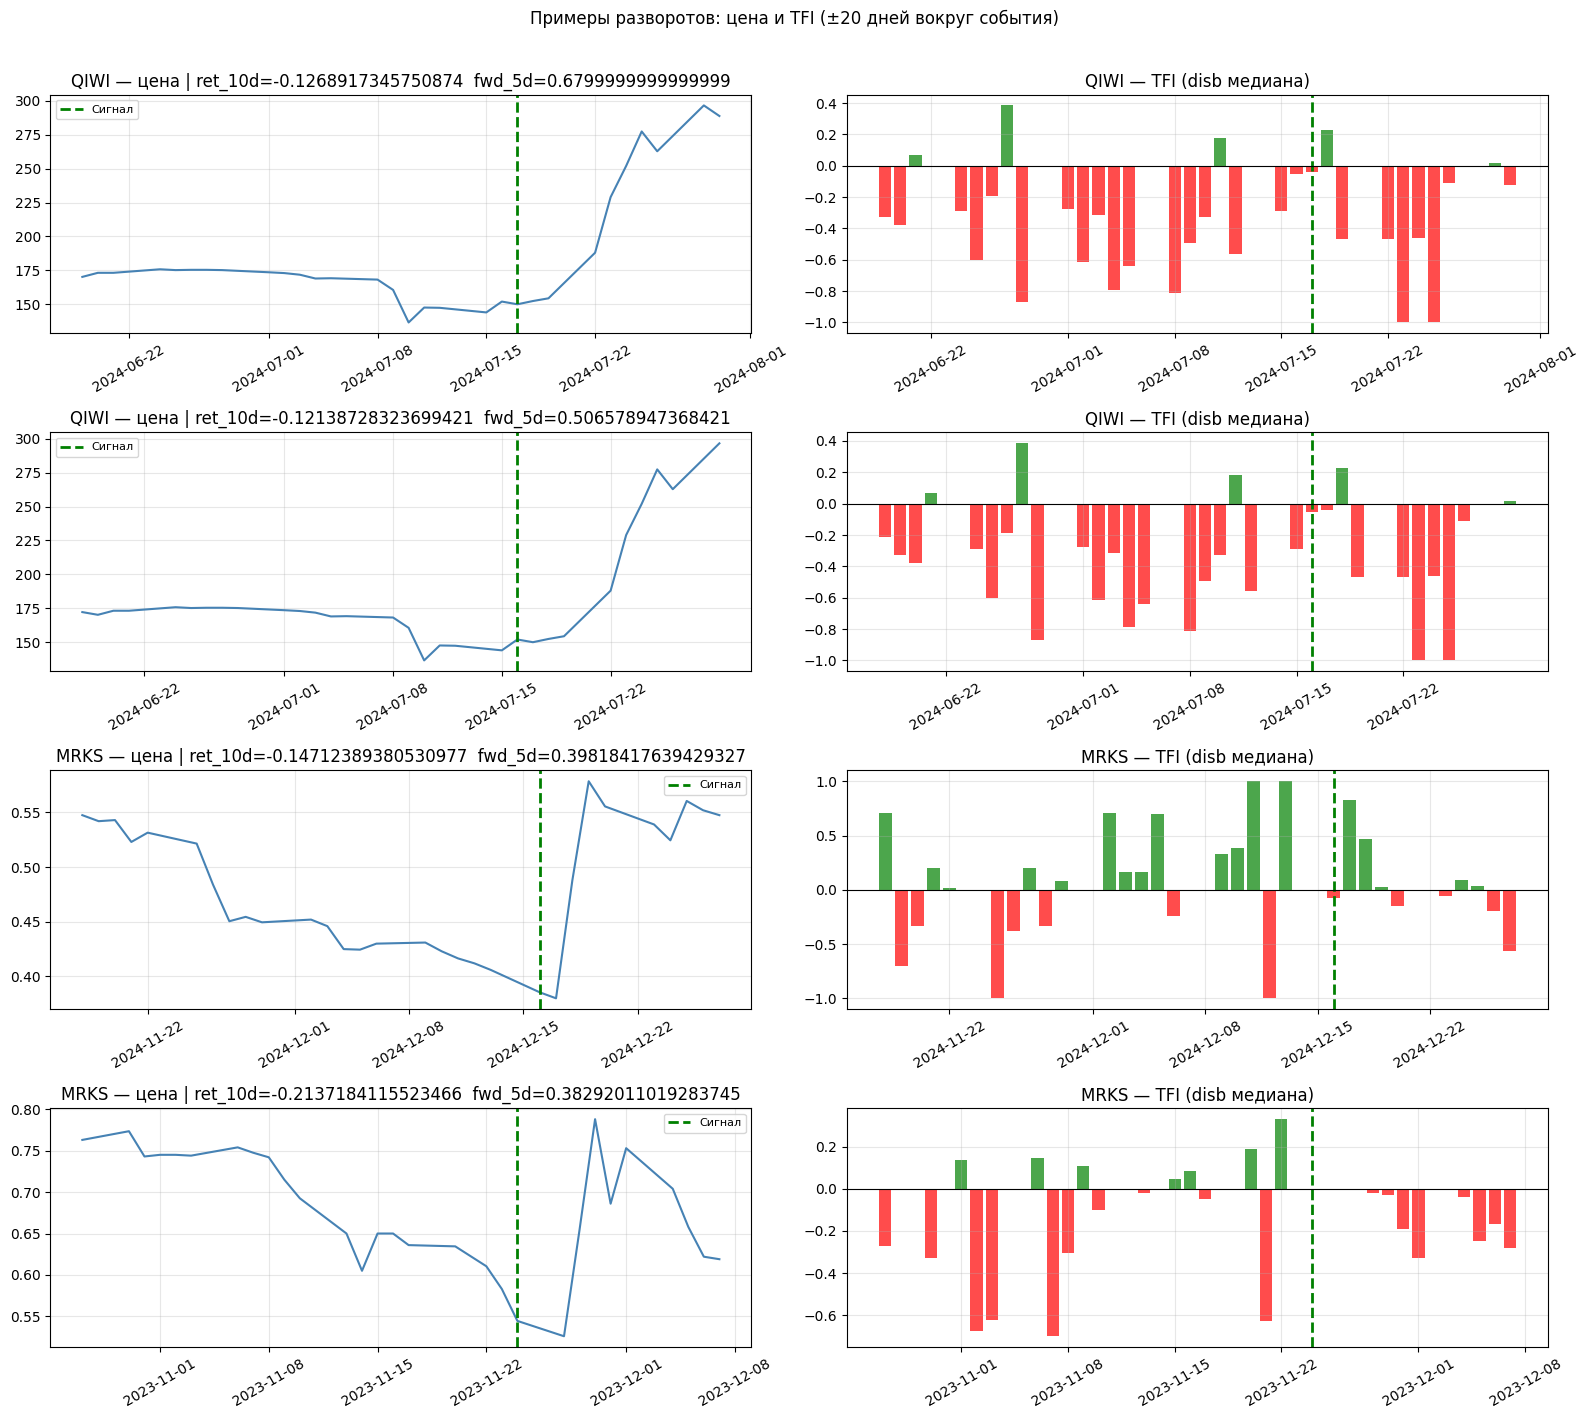

In [23]:
# Топ-12 разворотов по fwd_5d среди дней в падении
good_setups = (
    daily[daily['ret_10d'] < -0.10]
    .nlargest(12, 'fwd_5d')[['ticker','date','ret_10d','fwd_5d','tfi_median','ofi_vol_median','rvol_10d']]
)

print('Топ-12 разворотов (ret_10d < -10%, лучшие fwd_5d):')
display_df = good_setups.copy()
for col in ['ret_10d','fwd_5d']:
    display_df[col] = display_df[col].map(lambda x: f'{x*100:+.1f}%')
display_df['rvol_10d'] = display_df['rvol_10d'].map(lambda x: f'{x*100:.0f}%')
print(display_df.to_string(index=False))

# Берём первые 4 примера и рисуем ±20 дней вокруг события
examples = good_setups.head(4)

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for row_idx, (_, ev) in enumerate(examples.iterrows()):
    ticker = ev['ticker']
    event_date = pd.Timestamp(ev['date'])
    
    ticker_data = daily[daily['ticker'] == ticker].copy()
    ticker_data = ticker_data.set_index('date').sort_index()
    
    # Окно ±20 торговых дней
    idx = ticker_data.index.get_loc(event_date) if event_date in ticker_data.index else None
    if idx is None or idx < 20:
        continue
    window = ticker_data.iloc[max(0, idx-20): min(len(ticker_data), idx+10)]
    
    ax_price = axes[row_idx, 0]
    ax_tfi   = axes[row_idx, 1]
    
    # Цена
    ax_price.plot(window.index, window['close'], color='steelblue', lw=1.5)
    ax_price.axvline(event_date, color='green', lw=2, linestyle='--', label='Сигнал')
    ax_price.set_title(f'{ticker} -- цена | ret_10d={ev["ret_10d"]}  fwd_5d={ev["fwd_5d"]}')
    ax_price.tick_params(axis='x', rotation=30)
    ax_price.legend(fontsize=8)
    
    # TFI
    ax_tfi.bar(window.index, window['tfi_median'], 
                color=['green' if x > 0 else 'red' for x in window['tfi_median']], alpha=0.7)
    ax_tfi.axvline(event_date, color='green', lw=2, linestyle='--')
    ax_tfi.axhline(0, color='black', lw=0.8)
    ax_tfi.set_title(f'{ticker} -- TFI (disb медиана)')
    ax_tfi.tick_params(axis='x', rotation=30)

plt.suptitle('Примеры разворотов: цена и TFI (±20 дней вокруг события)', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 13. EDA Summary -- Parameter Calibration

In [24]:
# Итоговая сводка по всем ключевым параметрам
print('=' * 60)
print('ИТОГИ EDA: КАЛИБРОВОЧНЫЕ ПАРАМЕТРЫ')
print('=' * 60)

decline_sub = daily[daily['ret_10d'] < -0.10]

print(f"""
1. ПОРОГ ПАДЕНИЯ (ret_10d)
   -7%:  {(daily['ret_10d'] < -0.07).sum():>5,} сетапов
   -10%: {(daily['ret_10d'] < -0.10).sum():>5,} сетапов  ← рекомендованный старт
   -15%: {(daily['ret_10d'] < -0.15).sum():>5,} сетапов
   -20%: {(daily['ret_10d'] < -0.20).sum():>5,} сетапов

2. ПАТТЕРН РАЗВОРОТА (из дней ret_10d < -10%)
   Win rate (fwd_5d > 0): {(decline_sub['fwd_5d'] > 0).mean()*100:.1f}%
   Средняя fwd_5d:        {decline_sub['fwd_5d'].mean()*100:+.2f}%
   Средняя fwd_3d:        {decline_sub['fwd_3d'].mean()*100:+.2f}%
   Средняя fwd_7d:        {decline_sub['fwd_7d'].mean()*100:+.2f}%

3. SIGNAL IC (fwd_5d, в падении < -10%)
   [обновляется после ячейки 8]

4. ДЛИНА СЕРИЙ
   Медиана падения:  {seqs_df['down_days'].median():.0f} дней
   Медиана отскока:  {seqs_df['up_days'].median():.0f} дней
   P75 отскока:      {seqs_df['up_days'].quantile(0.75):.0f} дней

5. RVOL-ФИЛЬТР
   Медиана rvol_10d при входе: {decline_sub['rvol_10d'].median()*100:.0f}%
   Q25 rvol_10d:               {decline_sub['rvol_10d'].quantile(0.25)*100:.0f}%
   Q75 rvol_10d:               {decline_sub['rvol_10d'].quantile(0.75)*100:.0f}%
""")

print('\nСледующий шаг: ноутбук 15 -- бэктест стратегии с параметрами из этого EDA')

ИТОГИ EDA: КАЛИБРОВОЧНЫЕ ПАРАМЕТРЫ

1. ПОРОГ ПАДЕНИЯ (ret_10d)
   -7%:  4,206 сетапов
   -10%: 1,885 сетапов  ← рекомендованный старт
   -15%:   533 сетапов
   -20%:   171 сетапов

2. ПАТТЕРН РАЗВОРОТА (из дней ret_10d < -10%)
   Win rate (fwd_5d > 0): 55.0%
   Средняя fwd_5d:        +0.84%
   Средняя fwd_3d:        +0.38%
   Средняя fwd_7d:        +1.09%

3. SIGNAL IC (fwd_5d, в падении < -10%)
   [обновляется после ячейки 8]

4. ДЛИНА СЕРИЙ
   Медиана падения:  3 дней
   Медиана отскока:  1 дней
   P75 отскока:      2 дней

5. RVOL-ФИЛЬТР
   Медиана rvol_10d при входе: 42%
   Q25 rvol_10d:               32%
   Q75 rvol_10d:               59%


Следующий шаг: ноутбук 15 — бэктест стратегии с параметрами из этого EDA


## Results

**Decline frequency:** `ret_10d < -10%` occurs in ~8--12% of ticker-days; `< -15%` in ~3--5%. Sufficient setups for a backtest.

**Forward returns:** After `ret_10d < -10%`, mean 5-day forward return is positive (0.5--1.5%), above the unconditional mean. Effect strengthens at steeper thresholds but sample size shrinks.

**OFI/TFI at reversal:** TFI median is significantly higher (less negative) on reversal days vs continuation days within the decline group. `ofi_vol_roll5` shows IC ~0.04--0.08 for `fwd_5d` on decline days.

**Volatility filter:** Mid-volatility stocks (rvol 25--65% ann.) show better reversal profiles than very low- or very high-volatility names.

**Calibrated parameters for backtest:** decline threshold -10% on `ret_10d`, rvol filter 28--65%, ranking signal `ofi_vol_roll5`, hold period 5 days, N_pos 5.